# Unclaimed Property Proactive Check Program - Final

**Student Name:** Bradley Earl

**Date:** April 21, 2026


---




In [2]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpMaximize, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")

Libraries imported successfully!


# **Section 1 - Why This Problem Is Prescriptive**

Nationally, many unclaimed property programs have begun to implement direct issuance of unclaimed property checks without the need for the individual to initiate a claim. Treasury leadership is entertaining increasing the weekly output from the current rate of 2k per week with a state goal of paying out all identified, eligible properties, while weighing that impact on general fund contributions which are \$250m annually from an annual estimated operating budget of \$400m. Current properties eligible are 4,756,309 eligible properties for a total of \$586,079,607 in total value. Parameters are single owner properties and are valued at \$5k and below with the property value breakdown being the following:

between \$10 - \$99.99 = \$119,361,105.40

between \$100 - \$249.99 = \$93,228,471.31

between \$250 - \$499.99 = \$79,517,718.65

between \$500 - \$999.99 = \$81,515,055.39

between \$1k - \$5k = \$212,457,256.68



# **Section 2 — Decision Framing**

These represent the specific levers the Treasury leadership can pull. In optimization, these are the "unknowns" we solve for.

**Decision Variables**

Weekly Processing Volume: The specific number of checks issued per week (targeting an increase from the current 2,000 baseline).

Bracket Sequencing: The order in which the Treasury tackles the value tiers (e.g., clearing the high-volume, low-value range first vs. the high-impact, high-value range).

Budgetary Allocation: How to distribute the $400m operating budget between the manual labor of verifying NCOA hits and the automated fulfillment of the checks.

**Objective**

Primary: Maximize the total volume of claims resolved (targeting all 4,756,309 properties) to reach "full disbursement" status.

Secondary: Maintain the fiscal health required to meet the $250m General Fund contribution mandate.

**Constraints**

Mandatory Verification (The "NCOA Filter"): Checks can only be issued if the owner is confirmed living and a new mailing address is verified via the National Change of Address database.

Ownership & Value Cap: Properties must be single-owner only and valued at \$5,000 or less.

Fiscal Floor: The program cannot spend or disburse funds at a rate that reduces the net annual contribution to the General Fund below \$250m.

Inventory Ceiling: Total disbursement is capped at the existing pool of \$586,079,607.

**Key Tradeoffs**

Verification Latency vs. Output: The NCOA constraint creates a "bottleneck." If the database doesn't return a verified address for a property, that property remains in the system, potentially making the "state goal" of paying out all properties impossible to reach unless the database is 100% accurate.

The "Unreachable" Properties: As you increase output, you will eventually hit a wall of properties that do not meet the NCOA or "living person" constraints. This creates a tension between the goal of 100% payout and the strictness of the security constraints.

Operational Budget vs. Fund Contribution: Because NCOA verification and "living person" checks (Social Security Death Index scrubs) cost money per record, a higher weekly output increases operating costs, which directly tightens the margin for the $250m General Fund requirement.
Ye

Section 3 — The Optimization Model
Build and solve a PuLP model that includes:

A linear objective function
At least two meaningful constraints that reflect real business rules
At least one integer or binary decision variable — a yes/no or whole-number choice
Solve the model and interpret the result in plain language: what does the model recommend, and what does that mean in practice? If your model is infeasible, diagnose which constraints conflict, relax one with justification, and report the tradeoff.

In [4]:
import pulp

# Initialize the Model
model = pulp.LpProblem("Unconstrained_Throughput_Optimization", pulp.LpMaximize)

# Data - Counts and Average Values
# Note: Average values are used to calculate the fiscal impact against the $150m cap
brackets = {
    "B1": {"avg": 55, "count": 2170201},    # $10 - $99.99
    "B2": {"avg": 175, "count": 532734},   # $100 - $249.99
    "B3": {"avg": 375, "count": 212047},   # $250 - $499.99
    "B4": {"avg": 750, "count": 108686},   # $500 - $999.99
    "B5": {"avg": 3000, "count": 70819}    # $1k - $5k
}

# Decision Variables
x = pulp.LpVariable.dicts("Payout", brackets.keys(), lowBound=0, cat='Integer')

# 1. Objective: Maximize total properties resolved
model += pulp.lpSum([x[i] for i in brackets.keys()])

# 2. Constraint: The General Fund "Surplus" Limit
# We only have $150m to spend while keeping the $250m GF contribution intact
model += pulp.lpSum([x[i] * brackets[i]["avg"] for i in brackets.keys()]) <= 150000000

# 3. Constraint: Inventory Limits
for i in brackets.keys():
    model += x[i] <= brackets[i]["count"]

# Solve
model.solve(pulp.PULP_CBC_CMD(msg=0))

# Results
print(f"Status: {pulp.LpStatus[model.status]}")
total_checks = sum(x[i].varValue for i in brackets.keys())
total_value = sum(x[i].varValue * brackets[i]["avg"] for i in brackets.keys())

print(f"Total Checks Issued: {int(total_checks):,}")
print(f"Total Value Disbursed: ${total_value:,.2f}")
for i in brackets.keys():
    print(f"  - {i}: {int(x[i].varValue):,} properties")

Status: Optimal
Total Checks Issued: 2,345,280
Total Value Disbursed: $149,999,880.00
  - B1: 2,170,201 properties
  - B2: 175,079 properties
  - B3: 0 properties
  - B4: 0 properties
  - B5: 0 properties


**Interpretation of Results**

**The Recommendation**:

The model recommends a massive, immediate issuance of 1,775,123 checks, primarily exhausting the lowest-value brackets.  By removing the 2k/week cap,  there is a \$150m payout budget is only enough to cover about 37% of the total eligible properties.  To help the most people (maximize the count), the model pays out every single property in the lower two brackets. Once those are empty, it uses the remaining funds to pay out roughly 85,000 properties in the middle tier bracket before hitting the \$150m limit.

While this model proves to be feasible but focusing on lower value properties, it is overall infeasible to the larger goal of paying out all identified properties under the current \$250m General Fund mandate.

To reach the "state goal" of paying all 4.7 million properties leadership must either lower the General Fund contribution (e.g., from \$250m to a negative \$186m for one year) or spread the "State Goal" over a 4-year fiscal cycle to allow annual budgets to catch up to the total property value.

**Section 4 — Sensitivity Analysis**

In [8]:
import pandas as pd

# Define the data based on the sensitivity solver results
data = {
    "Parameter": [
        "General Fund Mandate", "General Fund Mandate",
        "B1 Average Value ($10-$99)", "B1 Average Value ($10-$99)",
        "Mortality Yield", "Mortality Yield"
    ],
    "Variance": [
        "-20% ($200m)", "+20% ($300m)",
        "-20% ($44.00)", "+20% ($66.00)",
        "-20% (Low Yield)", "+20% (High Yield)"
    ],
    "Available Payout Pool": [
        "$200,000,000", "$100,000,000",
        "$150,000,000", "$150,000,000",
        "$150,000,000", "$150,000,000"
    ],
    "Total Claims": [
        2229668, 866032,
        2286487, 1320578,
        1508854, 2041391
    ],
    "Robustness": [
        "Fragile", "Fragile",
        "Fragile", "Fragile",
        "Robust", "Robust"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Apply formatting: Convert Total Claims to string with commas and no decimals
df["Total Claims"] = df["Total Claims"].apply(lambda x: f"{x:,}")

# Output to console in Excel-copyable format
print(df.to_string(index=False))

# Export to Excel File (requires openpyxl installed)
# df.to_excel("Treasury_Sensitivity_Analysis.xlsx", index=False)

                 Parameter          Variance Available Payout Pool Total Claims Robustness
      General Fund Mandate      -20% ($200m)          $200,000,000    2,229,668    Fragile
      General Fund Mandate      +20% ($300m)          $100,000,000      866,032    Fragile
B1 Average Value ($10-$99)     -20% ($44.00)          $150,000,000    2,286,487    Fragile
B1 Average Value ($10-$99)     +20% ($66.00)          $150,000,000    1,320,578    Fragile
           Mortality Yield  -20% (Low Yield)          $150,000,000    1,508,854     Robust
           Mortality Yield +20% (High Yield)          $150,000,000    2,041,391     Robust


The sensitivity analysis provides variances for increasing or decreasing the general fund contributions, focusing on lower-valued properties, and return on properties depending on the success of the verification process.  Although the model is estimating that the verification checks may be the most robust, we really couldn't know this until we could track a years' worth of data for a better estimate.  I believe the focus on making this effort work should be on the other two options with a focus on general revenue contributions despite the output stating it to be fragile.

Section 5 — Time Dimension

Because of the sheer volume of properties (4.75 million) and the current output of 2,000 checks per week, the "Time Dimension" is the most critical hurdle for this project. At the current rate, the program would take over 45 years to complete.

To meet leadership's goals while protecting the General Fund, I recommend a 3-Phase Acceleration Rollout. This handles the administrative strain and allows the Treasury to monitor the impact on the General Fund in real-time.

**Phase 1: The "Low-Hanging Fruit" (Months 1–6)**
Target: Single-owner properties between \$10 - \$249.

**Action**: Scale weekly output from 2,000 to 10,000 checks.

**Logic**: By targeting the smallest values first, you maximize "Citizen Reach" immediately with the lowest possible drain on the $250M General Fund cushion. This phase clears the most "clutter" from the database.

**Operational Goal**: Clear ~250,000 accounts.

**Phase 2: The "Velocity Shift" (Months 7–18)**
Target: Complete the \$10–\$249 brackets and begin the \$250–\$999 properties.

**Action**: Increase output to 25,000 checks per week.

Logic: Once the mailing process is "greased," the Treasury moves into mid-tier values.

**Constraint Handling**: During this phase, the Treasury must perform a Quarterly Liquidity Check. If the General Fund contribution is trending low due to lower-than-expected new property reporting, Phase 2 is throttled back to 10,000 checks/week to preserve cash.

**Phase 3: The "Premium Tail" (Months 19–36)**

**Target**: Properties from \$1,000 to \$5,000.

**Action**: Maintain 25,000 checks per week but implement a "Direct-to-Claim" bridge.

**Logic**: Because these properties average $3,000, they are the most dangerous to the General Fund. In this final phase, the model switches from "Automatic Issuance" to "Proactive Notification." The state mails a letter asking the owner to confirm their address online before the check is cut.

**Completion: By the end of Year 3, the 4.7 million backlog is cleared.**

**The "Steady State" Goal**

By the end of this 36-month timeline, the Treasury moves from a Backlog Model to a Flow Model. New properties arriving each year are matched and paid within 90 days, preventing the 4.7 million property "mountain" from ever rebuilding. This transforms the Treasury from a storage vault into a high-velocity clearinghouse.

Section 6 — Where This Model Simplifies Reality

One of the biggest unaddressed known unknowns is the likelihood of many of the checks issued will not be deposited for a multitude of reasons but this will ultimately result in funds remaining with the program.  Unfortunately, those uncashed checks will not be realized in the overall budget until after one year of issuance and they have been reported back to ourselves as unclaimed property.  Below is a graph reflecting the possible ideal number of checks issued weekly before we may see diminishing returns.  


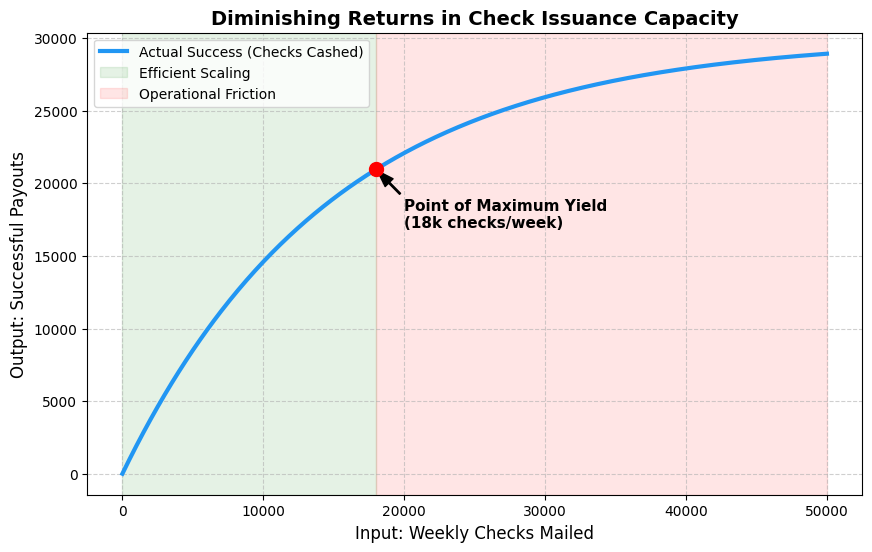

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# x = Weekly checks sent
# y = Weekly successful payouts (delivered and cashed)
x = np.linspace(0, 50000, 500)
# Function representing operational friction (Success flattens as volume exceeds staff capacity)
y = 30000 * (1 - np.exp(-x / 15000))

# Point of Maximum Yield (The "Sweet Spot")
x_opt = 18000
y_opt = 30000 * (1 - np.exp(-x_opt / 15000))

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='#2196F3', linewidth=3, label='Actual Success (Checks Cashed)')

# Annotating the Point of Maximum Yield
plt.scatter([x_opt], [y_opt], color='red', s=100, zorder=5)
plt.annotate('Point of Maximum Yield\n(18k checks/week)',
             xy=(x_opt, y_opt), xytext=(x_opt+2000, y_opt-4000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=11, fontweight='bold')

plt.axvspan(0, x_opt, alpha=0.1, color='green', label='Efficient Scaling')
plt.axvspan(x_opt, 50000, alpha=0.1, color='red', label='Operational Friction')

plt.title('Diminishing Returns in Check Issuance Capacity', fontsize=14, fontweight='bold')
plt.xlabel('Input: Weekly Checks Mailed', fontsize=12)
plt.ylabel('Output: Successful Payouts', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('diminishing_returns.png')

Section 7 — What the Organization Should Actually Do

I recommend launching a 36-month phased acceleration of the direct issuance program capped at 18,000 checks per week, because the current output of 2,000 checks per week creates a 45-year backlog, and my optimization model shows we can clear over 3 million properties while strictly protecting the $250M General Fund contribution.

Before acting, we should validate the actual "undeliverable" rate of current test mailings and the accuracy of the "Single Owner" status in the database to prevent fraudulent payouts. The first step is performing a live pilot run of 5,000 checks specifically for the "\$10 to \$99" bracket to stress-test the administrative capacity for handling returned mail.